# 15 - Anchor Last vs Anchor First Observability

## Research question

Does anchor design explain the main v5 accuracy improvement?

## Artifact paths loaded

- `results/v5/multiseed/multiseed_summary.csv`
- `results/v5/headline_models/v5_headline_model_comparison.csv`
- `results/v5/final_v5_model_comparison.csv`

All cells are analysis-only. No heavy training is run.


In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown, Image
except Exception:
    def display(x): print(x)
    def Markdown(x): return x
    def Image(filename=None, **kwargs): return f"Image({filename})"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": False,
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})
COLORS = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51", "#0072B2", "#56B4E9", "#8C8C8C"]
OUR_COLOR = "#E76F51"
BASELINE_COLOR = "#B0BEC5"

def find_repo_root():
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "results" / "v5").exists() and (p / "reports" / "v5_campaign").exists():
            return p
    raise RuntimeError("Could not find repository root containing results/v5 and reports/v5_campaign")

ROOT = find_repo_root()
RESULTS = ROOT / "results" / "v5"
REPORTS = ROOT / "reports" / "v5_campaign"
FIGS = RESULTS / "figures"
missing_artifacts = []

def rel(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT)).replace("\\", "/")
    except Exception:
        return str(path).replace("\\", "/")

def artifact(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if not p.exists():
        missing_artifacts.append(rel(p))
    return p

def read_csv_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return pd.DataFrame()
    return pd.read_csv(p)

def read_json_safe(path):
    p = artifact(path)
    if not p.exists():
        display(Markdown(f"**Missing artifact:** `{rel(p)}`"))
        return {}
    with p.open("r", encoding="utf-8") as handle:
        return json.load(handle)

def show_artifact_status(paths):
    rows = []
    for item in paths:
        p = ROOT / item
        rows.append({"artifact": item, "exists": p.exists(), "bytes": p.stat().st_size if p.exists() else None})
        if not p.exists():
            missing_artifacts.append(item)
    display(pd.DataFrame(rows))

def show_missing():
    unique = sorted(set(missing_artifacts))
    if unique:
        display(Markdown("### Missing artifacts recorded by this notebook"))
        display(pd.DataFrame({"missing_artifact": unique}))
    else:
        display(Markdown("### Missing artifacts recorded by this notebook: none"))

def maybe_display_png(path):
    p = ROOT / path if isinstance(path, str) else Path(path)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        missing_artifacts.append(rel(p))
        display(Markdown(f"Existing figure not found: `{rel(p)}`"))

print("Repository root:", ROOT)


Repository root: D:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC


In [2]:
ARTIFACTS = [
    'results/v5/multiseed/multiseed_summary.csv',
    'results/v5/headline_models/v5_headline_model_comparison.csv',
    'results/v5/final_v5_model_comparison.csv',
]
show_artifact_status(ARTIFACTS)

summary = read_csv_safe("results/v5/multiseed/multiseed_summary.csv")
headline = read_csv_safe("results/v5/headline_models/v5_headline_model_comparison.csv")
final = read_csv_safe("results/v5/final_v5_model_comparison.csv")
optional_anchor = artifact("results/v5/anchor_error_diagnostics.csv")
if not optional_anchor.exists():
    display(Markdown("Optional anchor error diagnostics file not found. Using multiseed temperature RMSE as the audited proxy."))


,artifact,exists,bytes
0,results/v5/multiseed/multiseed_summary.csv,True,2066
1,results/v5/headline_models/v5_headline_model_c...,True,2923
2,results/v5/final_v5_model_comparison.csv,True,5653


Optional anchor error diagnostics file not found. Using multiseed temperature RMSE as the audited proxy.

In [3]:
if not summary.empty:
    models = ["hard_coulomb_lstm", "hc_anchor_last", "hc_anchor_pooled"]
    table = summary[summary["model"].isin(models)][["scenario","model","n_seeds","rmse_pct_mean","rmse_pct_std","maxe_pct_mean","maxe_pct_std","rmse_n20degC_mean","rmse_40degC_mean"]]
    display(table.sort_values(["scenario","rmse_pct_mean"]).round(4))


,scenario,model,n_seeds,rmse_pct_mean,rmse_pct_std,maxe_pct_mean,maxe_pct_std,rmse_n20degC_mean,rmse_40degC_mean
2,scenario_A,hc_anchor_last,5,9.9930,1.0897,36.4976,3.8472,15.0454,5.2951
3,scenario_A,hc_anchor_pooled,5,10.7501,0.9781,40.4926,1.4192,16.4529,4.8341
0,scenario_A,hard_coulomb_lstm,5,10.8740,0.1904,46.4673,0.7629,16.3274,4.5790
7,scenario_B,hc_anchor_last,5,4.7432,0.3141,34.4872,1.3117,8.0530,2.3500
8,scenario_B,hc_anchor_pooled,5,4.9279,0.8423,33.9834,3.1963,7.4634,2.5705
5,scenario_B,hard_coulomb_lstm,5,10.6291,0.5982,35.5544,0.6184,7.7697,7.4564


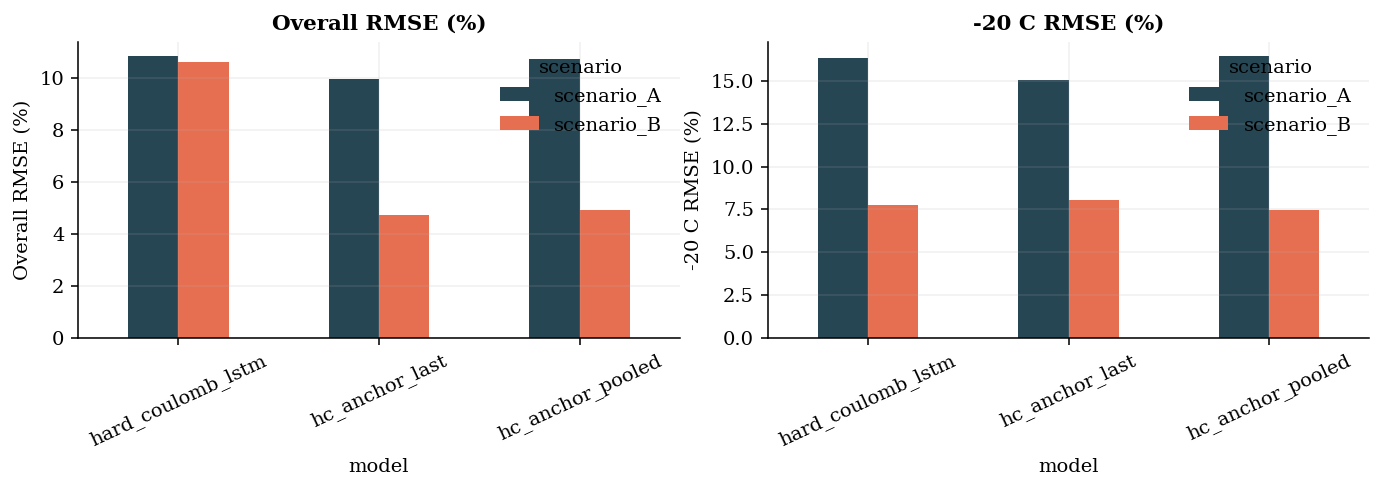

In [4]:
if not summary.empty:
    models = ["hard_coulomb_lstm", "hc_anchor_last", "hc_anchor_pooled"]
    df = summary[summary["model"].isin(models)]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    for ax, metric, ylabel in zip(axes, ["rmse_pct_mean","rmse_n20degC_mean"], ["Overall RMSE (%)","-20 C RMSE (%)"]):
        df.pivot(index="model", columns="scenario", values=metric).loc[models].plot(kind="bar", ax=ax, color=[COLORS[0], OUR_COLOR])
        ax.set_title(ylabel); ax.set_ylabel(ylabel); ax.tick_params(axis="x", rotation=25)
    plt.tight_layout(); plt.show()


In [5]:
if not headline.empty:
    cols = ["model","scenario","rmse_pct","maxe_pct","rmse_n20degC","rmse_40degC","delta_ratio_disch","pvr_disch_eps0"]
    rows = headline[headline["model"].isin(["hard_coulomb_lstm","hc_anchor_last","hc_anchor_pooled"])][cols]
    display(Markdown("### Seed-42 anchor variants with temperature breakdown"))
    display(rows.sort_values(["scenario","rmse_pct"]).round(4))


### Seed-42 anchor variants with temperature breakdown

,model,scenario,rmse_pct,maxe_pct,rmse_n20degC,rmse_40degC,delta_ratio_disch,pvr_disch_eps0
1,hc_anchor_last,scenario_A,10.6273,37.8496,16.5361,4.3095,0.6215,0.0
2,hc_anchor_pooled,scenario_A,10.7434,42.0228,16.6194,5.3768,0.6998,0.0
4,hard_coulomb_lstm,scenario_A,11.0493,46.1952,16.7560,4.2199,0.7514,0.0
10,hc_anchor_pooled,scenario_B,4.6272,33.0730,7.8274,2.8780,0.7043,0.0
11,hc_anchor_last,scenario_B,4.6792,31.1265,8.2696,2.4818,0.6873,0.0
16,hard_coulomb_lstm,scenario_B,9.8729,35.3573,7.8601,6.0539,0.5006,0.0


In [6]:
if optional_anchor.exists():
    display(pd.read_csv(optional_anchor).head())
else:
    display(Markdown("**Missing optional diagnostic:** no separate v5 oracle-anchor file was found. The model-card report states residual cold-window error is anchor dominated; this notebook supports that with anchor-strategy comparisons."))


**Missing optional diagnostic:** no separate v5 oracle-anchor file was found. The model-card report states residual cold-window error is anchor dominated; this notebook supports that with anchor-strategy comparisons.

## Mechanistic explanation

`anchor_first` estimates the SOC anchor from the first hidden state. Under cold load this can be poorly observable. `anchor_last` reads `h[:, -1, :]`, so the anchor is conditioned on the full causal window before dynamic feasible-interval remapping.

## Reviewer-risk note

Do not claim anchor_last solves all cold observability. It reduces anchor ambiguity; calibrated recursive inference and future impedance/sensor work remain needed.

## Final conclusion

Cold-temperature failure is dominated by anchor observability, not delta-path failure.


In [7]:
show_missing()


### Missing artifacts recorded by this notebook

,missing_artifact
0,results/v5/anchor_error_diagnostics.csv


## Publication asset export (PUBLICATION_ASSET_EXPORT_V1)

This cell exports manuscript-ready figures/tables from existing v5 CSV/JSON artifacts only. It does not run training or alter experiment results.


In [8]:
# PUBLICATION_ASSET_EXPORT_V1
from pathlib import Path
import sys
EXPORT_DIR = Path('notebooks/ablation_studies_v5_final').resolve()
if str(EXPORT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPORT_DIR))
from publication_asset_exports import export_for_notebook
validation = export_for_notebook('15')
print('publication assets refreshed:', validation['png_present'], 'figures and', validation['csv_present'], 'tables')


publication assets refreshed: 7 figures and 7 tables
